In [2]:
# open sep2012 run to investigate wvel rms
from xmitgcm import open_mdsdataset
import xarray as xr

prefix = 'diag_state'

data_dir = '/data/SO3/edavenport/tpose6/sep2012/run_iter14/'
grid_dir = '/data/SO6/TPOSE_diags/tpose6/grid_6/'

offset = 10
num_diags = 30+31+offset #sep, oct + 10 days
itPerFile = 72 # 1 day
intervals = range(itPerFile,itPerFile*num_diags,itPerFile)

ds = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-09-01',delta_t=1200)

num_diags = 30+31+offset# nov, dec (starting from nov 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/nov2012/run_iter20/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2012-11-01',delta_t=1200)

ds_tpose_vel = xr.concat([ds,ds_new],dim='time')

num_diags = 31+28+offset # jan, feb, (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/jan2013/run_iter14/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-01-01',delta_t=1200)

ds_tpose_vel = xr.concat([ds_tpose_vel,ds_new],dim='time')

num_diags = 31+30+31+30 # mar, apr, may, june (starting from jan 10)
itPerFile = 72 # 1 day
intervals = range(itPerFile*offset,itPerFile*num_diags,itPerFile)

data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'
ds_new = open_mdsdataset(data_dir=data_dir,grid_dir=grid_dir,iters=intervals,prefix=prefix,ref_date='2013-03-01',delta_t=1200)

ds_tpose_vel = xr.concat([ds_tpose_vel,ds_new],dim='time')

ds_tpose_vel['XC'] = ds_tpose_vel.XC.astype(float)
ds_tpose_vel['YC'] = ds_tpose_vel.YC.astype(float)
ds_tpose_vel['Z'] = ds_tpose_vel.Z.astype(float)
ds_tpose_vel['XG'] = ds_tpose_vel.XG.astype(float)
ds_tpose_vel['YG'] = ds_tpose_vel.YG.astype(float)
ds_tpose_vel['Zl'] = ds_tpose_vel.Zl.astype(float)

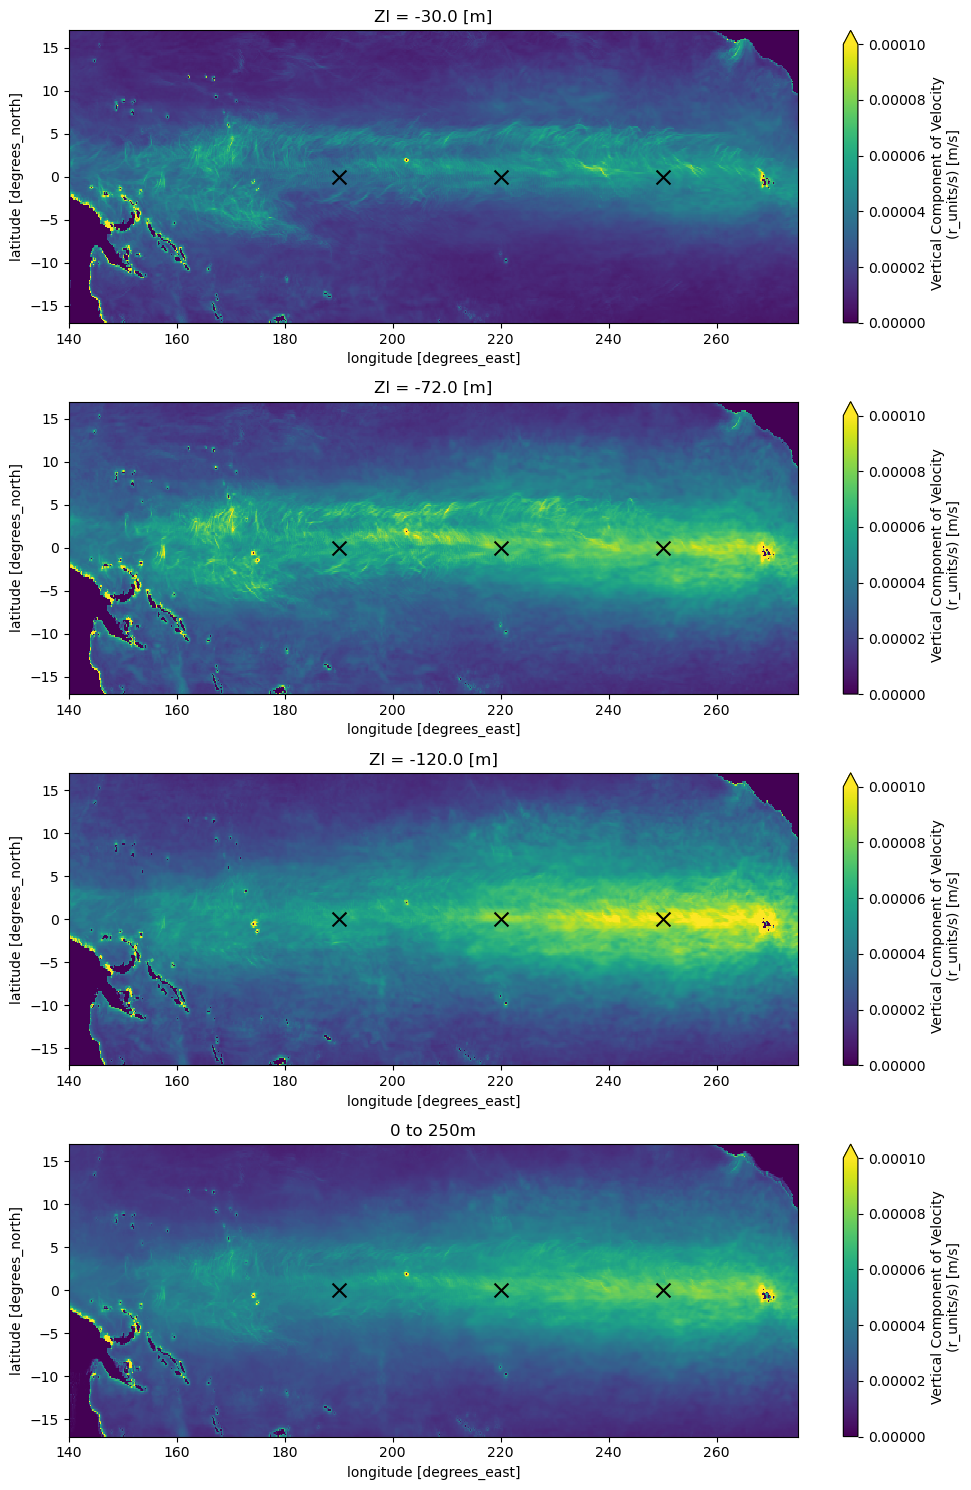

In [3]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,15),nrows=4)
wvel_rms = np.sqrt((ds_tpose_vel.WVEL.sel(Zl=-30,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[0],vmin=0,vmax=0.0001)
# scatter plot of moorings at 0N, 190E, 0N, 220E, and 0N, 250E
moorings = [(0,190),(0,220),(0,250)]
for lat,lon in moorings:
    ax[0].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds_tpose_vel.WVEL.sel(Zl=-70,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[1],vmin=0,vmax=0.0001)
for lat,lon in moorings:
    ax[1].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds_tpose_vel.WVEL.sel(Zl=-120,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[2],vmin=0,vmax=0.0001)
for lat,lon in moorings:
    ax[2].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds_tpose_vel.WVEL.sel(Zl=slice(0,-250))**2).mean(dim=['time','Zl']))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[3],vmin=0,vmax=0.0001)
for lat,lon in moorings:
    ax[3].scatter(lon,lat,color='k',marker='x',s=100)
ax[3].set_title("0 to 250m")

plt.tight_layout()
fig.savefig('assimilation_results/wvel_changes/wvel_rms.png',dpi=300)

In [4]:
from open_tpose import tpose2012to2013

ds = tpose2012to2013(prefix)

ds['XC'] = ds.XC.astype(float)
ds['YC'] = ds.YC.astype(float)
ds['Z'] = ds.Z.astype(float)
ds['XG'] = ds.XG.astype(float)
ds['YG'] = ds.YG.astype(float)
ds['Zl'] = ds.Zl.astype(float)

ds = ds.sel(time=slice('2012-09-01','2013-06-30'))

mar2013/diags_daily/
may2013/diags_daily/
jul2013/diags_daily/
sep2013/diags_daily/
nov2013/diags_daily/
Days in 2012-2013: (should be 731)
731


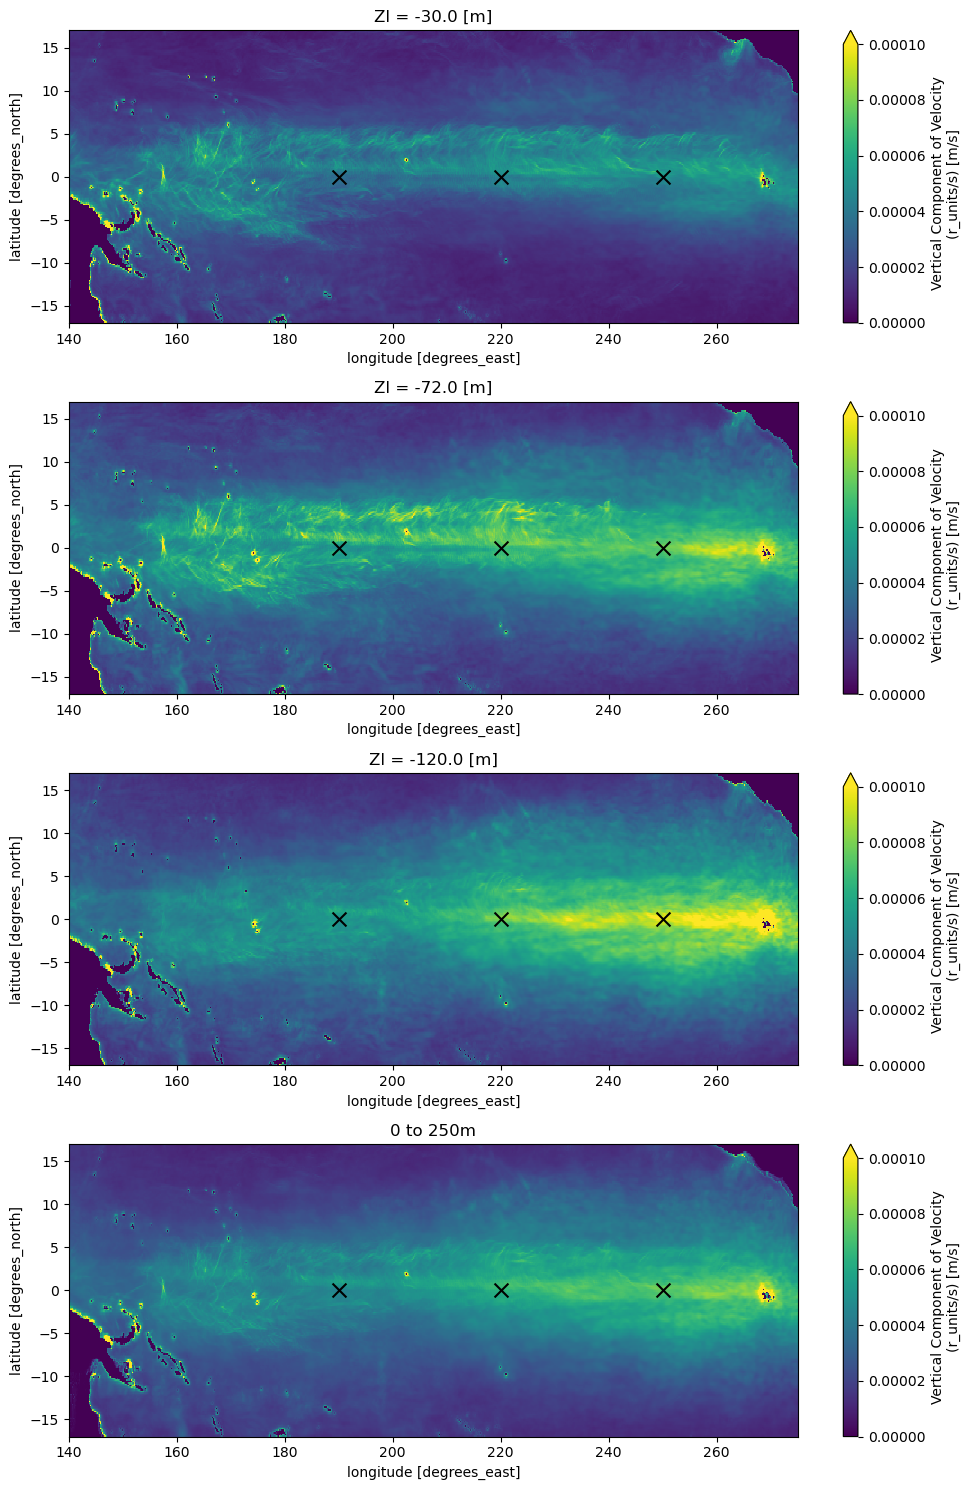

In [5]:

fig, ax = plt.subplots(figsize=(10,15),nrows=4)
wvel_rms = np.sqrt((ds.WVEL.sel(Zl=-30,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[0],vmin=0,vmax=0.0001)
# scatter plot of moorings at 0N, 190E, 0N, 220E, and 0N, 250E
moorings = [(0,190),(0,220),(0,250)]
for lat,lon in moorings:
    ax[0].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.WVEL.sel(Zl=-70,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[1],vmin=0,vmax=0.0001)
for lat,lon in moorings:
    ax[1].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.WVEL.sel(Zl=-120,method='nearest')**2).mean(dim='time'))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[2],vmin=0,vmax=0.0001)
for lat,lon in moorings:
    ax[2].scatter(lon,lat,color='k',marker='x',s=100)

wvel_rms = np.sqrt((ds.WVEL.sel(Zl=slice(0,-250))**2).mean(dim=['time','Zl']))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[3],vmin=0,vmax=0.0001)
for lat,lon in moorings:
    ax[3].scatter(lon,lat,color='k',marker='x',s=100)
ax[3].set_title("0 to 250m")

plt.tight_layout()
fig.savefig('assimilation_results/wvel_changes/wvel_rms_tpose_noVel.png',dpi=300)

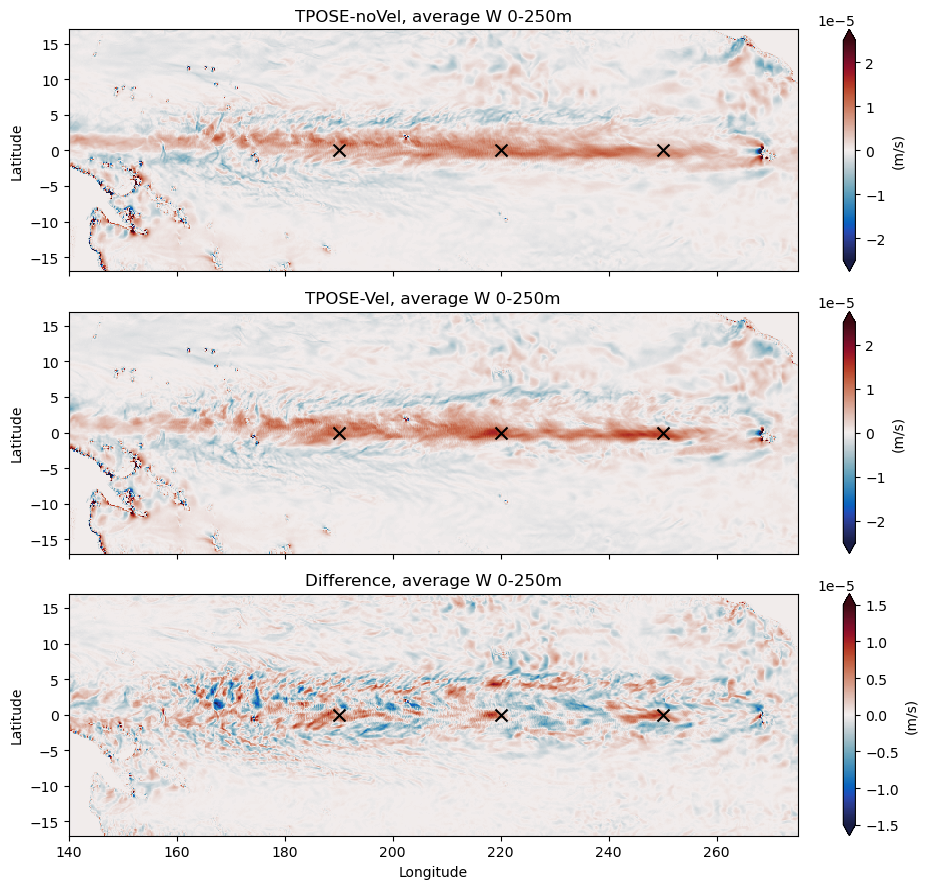

In [6]:
import cmocean.cm as cmo

fig, ax = plt.subplots(figsize=(10,9),nrows=3, sharex=True)
wvel_rms = ds.WVEL.sel(Zl=slice(0,-250)).mean(dim=['time','Zl'])
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[0],vmin=-0.000025,vmax=0.000025,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
# scatter plot of moorings at 0N, 190E, 0N, 220E, and 0N, 250E
moorings = [(0,190),(0,220),(0,250)]
for lat,lon in moorings:
    ax[0].scatter(lon,lat,color='k',marker='x',s=75)
ax[0].set_title('TPOSE-noVel, average W 0-250m')
ax[0].set_xlabel('')

wvel_rms = ds_tpose_vel.WVEL.sel(Zl=slice(0,-250)).mean(dim=['time','Zl'])
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[1],vmin=-0.000025,vmax=0.000025,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
for lat,lon in moorings:
    ax[1].scatter(lon,lat,color='k',marker='x',s=75)
ax[1].set_title('TPOSE-Vel, average W 0-250m')
ax[1].set_xlabel('')

wvel_rms = (ds_tpose_vel.WVEL.sel(Zl=slice(0,-250)).mean(dim=['time','Zl']) - ds.WVEL.sel(Zl=slice(0,-250)).mean(dim=['time','Zl']))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot(ax=ax[2],vmin=-0.000015,vmax=0.000015,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
for lat,lon in moorings:
    ax[2].scatter(lon,lat,color='k',marker='x',s=75)
ax[2].set_title("Difference, average W 0-250m")
ax[2].set_xlabel('Longitude')

for a in ax:
    a.set_ylabel('Latitude')

plt.tight_layout()
fig.savefig('assimilation_results/wvel_changes/wvel_difference.png',dpi=300,bbox_inches='tight')

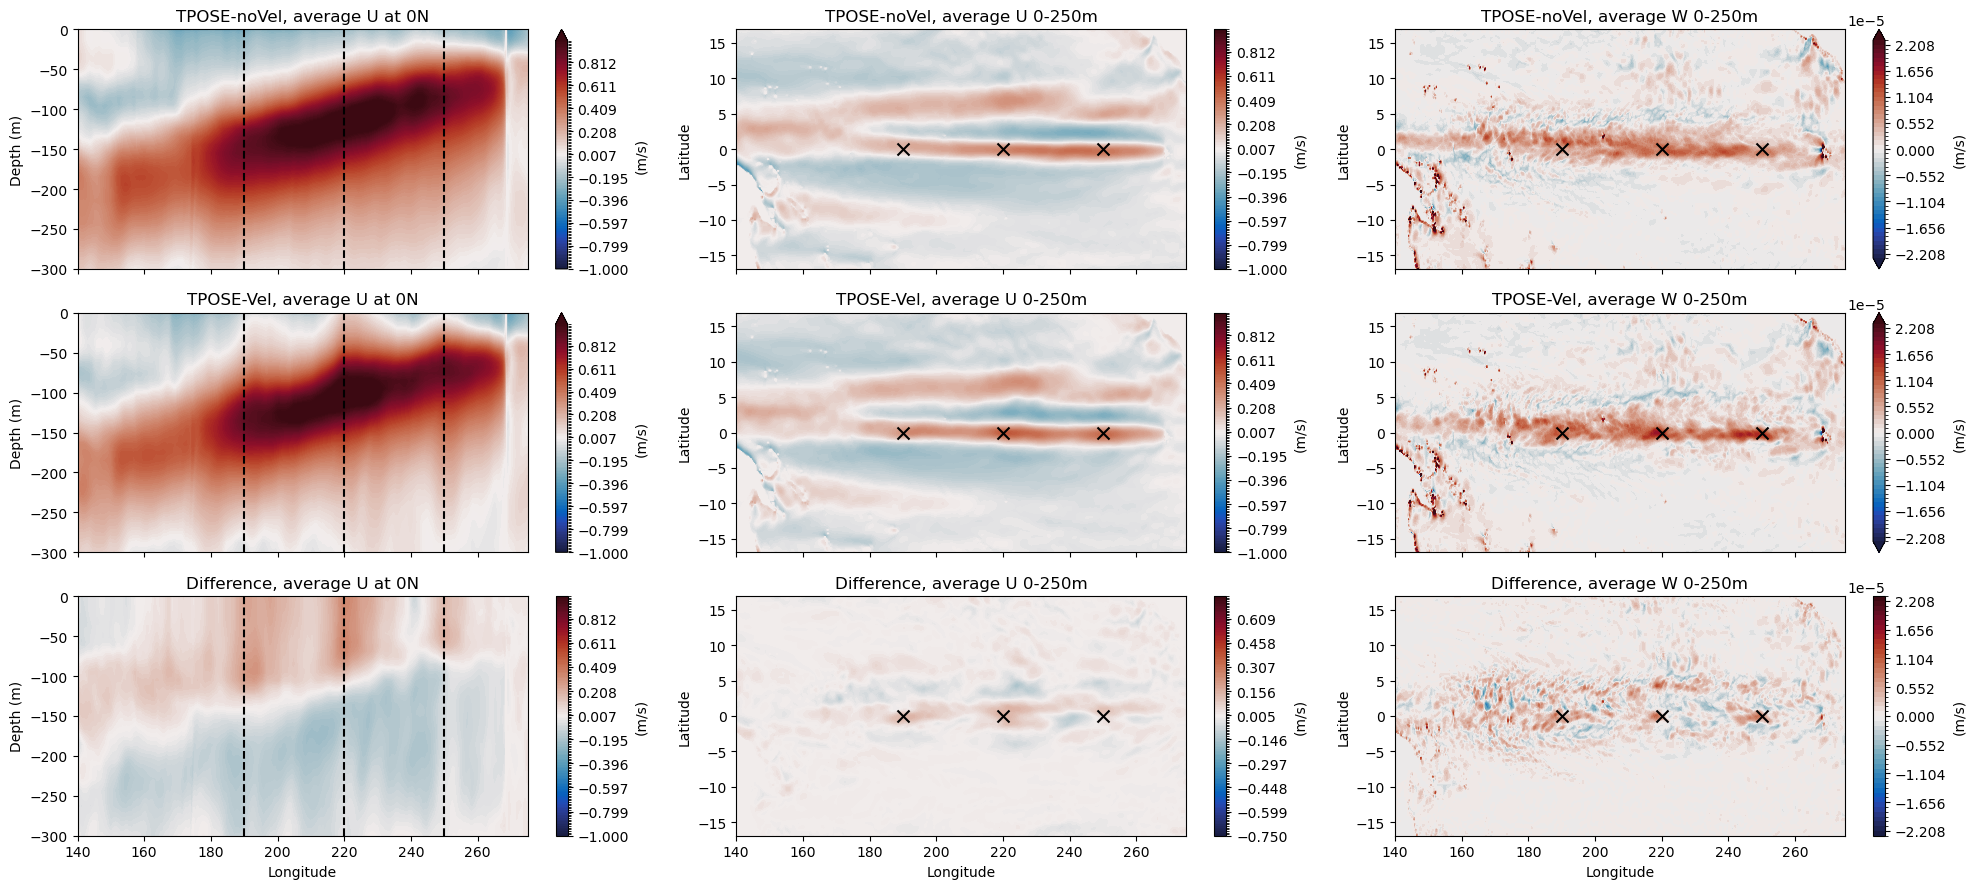

In [ ]:
# create the plot above, but add a time-mean Z v XC plot of UVEL. there should be two columns, one showing the WVEL analysis and one showing UVEL 
fig, ax = plt.subplots(figsize=(20,9),nrows=3, ncols=3, sharex=True)
lon_slice = slice(140,275)
levels = np.linspace(-1.0,1.0,150)
uvel_rms = ds.UVEL.sel(YC=0, method='nearest').sel(XG=lon_slice).mean(dim='time')
uvel_rms.plot.contourf(ax=ax[0,0],levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
ax[0,0].axvline(190,color='k',linestyle='--')
ax[0,0].axvline(220,color='k',linestyle='--')
ax[0,0].axvline(250,color='k',linestyle='--')
ax[0,0].set_ylim(-300,0)
ax[0,0].set_title('TPOSE-noVel, average U at 0N')
ax[0,0].set_xlabel('')

uvel_rms = ds_tpose_vel.UVEL.sel(YC=0, method='nearest').sel(XG=lon_slice).mean(dim='time')
uvel_rms.plot.contourf(ax=ax[1,0],levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
ax[1,0].axvline(190,color='k',linestyle='--')
ax[1,0].axvline(220,color='k',linestyle='--')
ax[1,0].axvline(250,color='k',linestyle='--')
ax[1,0].set_ylim(-300,0)
ax[1,0].set_title('TPOSE-Vel, average U at 0N')
ax[1,0].set_xlabel('')

uvel_rms = (ds_tpose_vel.UVEL.sel(YC=0, method='nearest').sel(XG=lon_slice).mean(dim='time') - ds.UVEL.sel(YC=0, method='nearest').sel(XG=lon_slice).mean(dim='time'))
uvel_rms.plot.contourf(ax=ax[2,0],levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
ax[2,0].axvline(190,color='k',linestyle='--')
ax[2,0].axvline(220,color='k',linestyle='--')
ax[2,0].axvline(250,color='k',linestyle='--')
ax[2,0].set_ylim(-300,0)
ax[2,0].set_title('Difference, average U at 0N')
ax[2,0].set_xlabel('Longitude')

lon_slice = slice(140,275)
levels = np.linspace(-1.0,1.0,150)
uvel_rms = ds.UVEL.sel(YC=slice(-17,17), XG=lon_slice, Z=slice(0,-250)).mean(dim=['time','Z'])
uvel_rms.plot.contourf(ax=ax[0,1],levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
moorings = [(0,190),(0,220),(0,250)]
for lat,lon in moorings:
    ax[0,1].scatter(lon,lat,color='k',marker='x',s=75)
ax[0,1].set_title('TPOSE-noVel, average U 0-250m')
ax[0,1].set_xlabel('')

uvel_rms = ds_tpose_vel.UVEL.sel(YC=slice(-17,17), XG=lon_slice, Z=slice(0,-250)).mean(dim=['time','Z'])
uvel_rms.plot.contourf(ax=ax[1,1],levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
for lat,lon in moorings:
    ax[1,1].scatter(lon,lat,color='k',marker='x',s=75)
ax[1,1].set_title('TPOSE-Vel, average U 0-250m')
ax[1,1].set_xlabel('')

levels = np.linspace(-0.5,0.5,150)
uvel_rms = (ds_tpose_vel.UVEL.sel(YC=slice(-17,17), XG=lon_slice, Z=slice(0,-250)).mean(dim=['time','Z']) - ds.UVEL.sel(YC=slice(-17,17), XG=lon_slice, Z=slice(0,-250)).mean(dim=['time','Z']))
uvel_rms.plot.contourf(ax=ax[2,1],levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
for lat,lon in moorings:
    ax[2,1].scatter(lon,lat,color='k',marker='x',s=75)
ax[2,1].set_title('Difference, average U 0-250m')
ax[2,1].set_xlabel('Longitude')

levels = np.linspace(-0.000023,0.000023,51)
wvel_rms = ds.WVEL.sel(Zl=slice(0,-250)).mean(dim=['time','Zl'])
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot.contourf(ax=ax[0,2],levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
# scatter plot of moorings at 0N, 190E, 0N, 220E, and 0N, 250E
for lat,lon in moorings:
    ax[0,2].scatter(lon,lat,color='k',marker='x',s=75)
ax[0,2].set_title('TPOSE-noVel, average W 0-250m')
ax[0,2].set_xlabel('')  

wvel_rms = ds_tpose_vel.WVEL.sel(Zl=slice(0,-250)).mean(dim=['time','Zl'])
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot.contourf(ax=ax[1,2],levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
for lat,lon in moorings:
    ax[1,2].scatter(lon,lat,color='k',marker='x',s=75)
ax[1,2].set_title('TPOSE-Vel, average W 0-250m')
ax[1,2].set_xlabel('')

levels = np.linspace(-0.000019,0.000019,51)
wvel_rms = (ds_tpose_vel.WVEL.sel(Zl=slice(0,-250)).mean(dim=['time','Zl']) - ds.WVEL.sel(Zl=slice(0,-250)).mean(dim=['time','Zl']))
wvel_rms.sel(XC=slice(140,275),YC=slice(-17,17)).plot.contourf(ax=ax[2,2],levels=levels,cmap=cmo.balance,cbar_kwargs={'label':'(m/s)'})
for lat,lon in moorings:
    ax[2,2].scatter(lon,lat,color='k',marker='x',s=75)
ax[2,2].set_title("Difference, average W 0-250m")
ax[2,2].set_xlabel('Longitude')

for a in ax[:,1]:
    a.set_ylabel('Latitude')
for a in ax[:,2]:
    a.set_ylabel('Latitude')
for a in ax[:,0]:
    a.set_ylabel('Depth (m)')
plt.tight_layout()
fig.savefig('assimilation_results/wvel_changes/wvel_uvel_difference.png',dpi=300,bbox_inches='tight')